In [17]:
# ==========================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [18]:
# ==========================================
# STEP 2 : LOAD DATASET
# ==========================================

df = pd.read_csv("/content/Iris.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
# ==========================================
# STEP 3 : EXPLORE DATASET
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594  

In [20]:
# ==========================================
# STEP 4 : CHECK MISSING VALUES
# ==========================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [21]:
df = df.dropna()

In [22]:
# ==========================================
# STEP 5 : REMOVE UNNECESSARY COLUMN
# ==========================================

if "Id" in df.columns:
    df = df.drop("Id", axis=1)

print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [23]:
# ==========================================
# STEP 6 : SELECT FEATURES AND TARGET
# ==========================================

X = df.drop("Species", axis=1)

y = df["Species"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [24]:
# ==========================================
# STEP 7 : ENCODE TARGET CLASSES
# ==========================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Encoded Classes:")
print(np.unique(y))

print("\nClass Names:")
print(encoder.classes_)

Encoded Classes:
[0 1 2]

Class Names:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


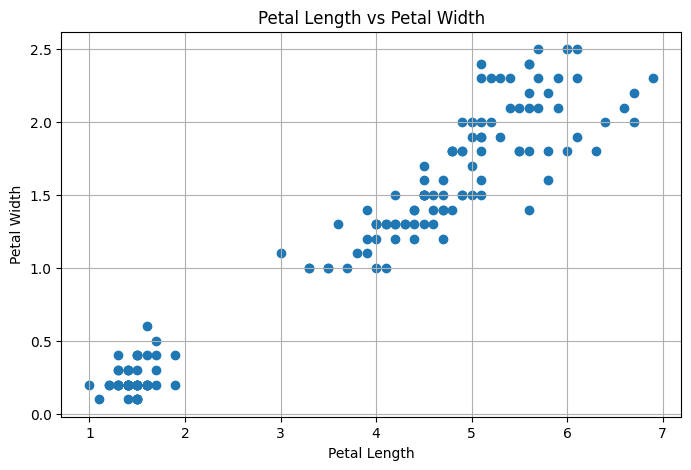

In [25]:
# ==========================================
# STEP 8 : VISUALIZE DATA
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["PetalLengthCm"],
    df["PetalWidthCm"]
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")

plt.grid(True)

plt.show()

In [26]:
# ==========================================
# STEP 9 : TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (120, 4)
Testing data shape : (30, 4)


In [27]:
# ==========================================
# STEP 10 : FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaled Training Data:")
print(X_train[:5])

Scaled Training Data:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


In [28]:
# ==========================================
# STEP 11 : CONVERT TO PYTORCH TENSORS
# ==========================================

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: torch.Size([120, 4])
X_test shape : torch.Size([30, 4])
y_train shape: torch.Size([120])
y_test shape : torch.Size([30])


In [29]:
# ==========================================
# STEP 12 : BUILD ANN MODEL
# ==========================================

class IrisANN(nn.Module):

    def __init__(self):

        super().__init__()

        # Input layer -> Hidden layer
        self.fc1 = nn.Linear(4, 16)

        # Hidden layer -> Hidden layer
        self.fc2 = nn.Linear(16, 8)

        # Hidden layer -> Output layer
        self.fc3 = nn.Linear(8, 3)

    def forward(self, x):

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.fc3(x)

        return x


model = IrisANN()

print(model)

IrisANN(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=3, bias=True)
)


In [30]:
# ==========================================
# STEP 13 : DEFINE LOSS FUNCTION
# ==========================================

criterion = nn.CrossEntropyLoss()

print("Loss Function:")
print(criterion)

Loss Function:
CrossEntropyLoss()


In [31]:
# ==========================================
# STEP 14 : DEFINE ADAM OPTIMIZER
# ==========================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

print("Optimizer:")
print(optimizer)

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [32]:
# ==========================================
# STEP 15 : TRAIN THE ANN
# ==========================================

epochs = 200

loss_history = []

accuracy_history = []

for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train)

    # Calculate loss
    loss = criterion(outputs, y_train)

    # Clear old gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Calculate training accuracy
    _, predicted = torch.max(outputs, 1)

    accuracy = (
        predicted == y_train
    ).float().mean()

    accuracy_history.append(
        accuracy.item()
    )

    # Print progress
    if (epoch + 1) % 20 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {loss.item():.4f} "
            f"Accuracy: {accuracy.item() * 100:.2f}%"
        )

Epoch [20/200] Loss: 0.5214 Accuracy: 81.67%
Epoch [40/200] Loss: 0.3120 Accuracy: 91.67%
Epoch [60/200] Loss: 0.1518 Accuracy: 97.50%
Epoch [80/200] Loss: 0.0508 Accuracy: 98.33%
Epoch [100/200] Loss: 0.0320 Accuracy: 98.33%
Epoch [120/200] Loss: 0.0259 Accuracy: 98.33%
Epoch [140/200] Loss: 0.0218 Accuracy: 98.33%
Epoch [160/200] Loss: 0.0183 Accuracy: 99.17%
Epoch [180/200] Loss: 0.0154 Accuracy: 100.00%
Epoch [200/200] Loss: 0.0128 Accuracy: 100.00%


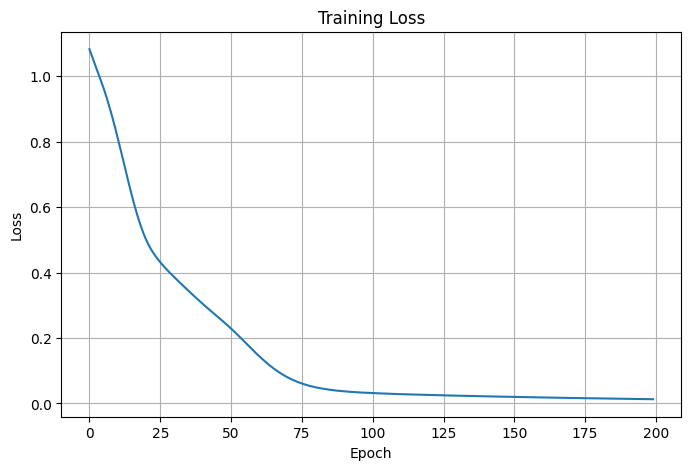

In [33]:
# ==========================================
# STEP 16 : PLOT TRAINING LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

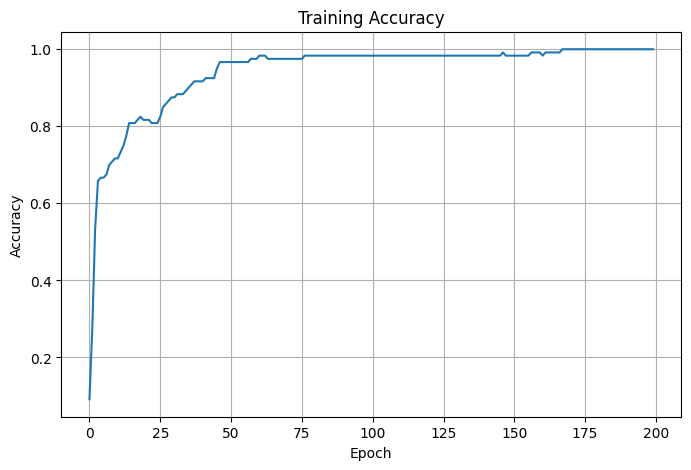

In [34]:
# ==========================================
# STEP 17 : PLOT TRAINING ACCURACY
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    accuracy_history
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.show()

In [35]:
# ==========================================
# STEP 18 : EVALUATE MODEL
# ==========================================

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    _, predicted = torch.max(
        outputs,
        1
    )

accuracy = accuracy_score(
    y_test.numpy(),
    predicted.numpy()
)

print(
    "Test Accuracy:",
    accuracy * 100,
    "%"
)

Test Accuracy: 96.66666666666667 %


In [36]:
# ==========================================
# STEP 19 : CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy(),
        target_names=encoder.classes_
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



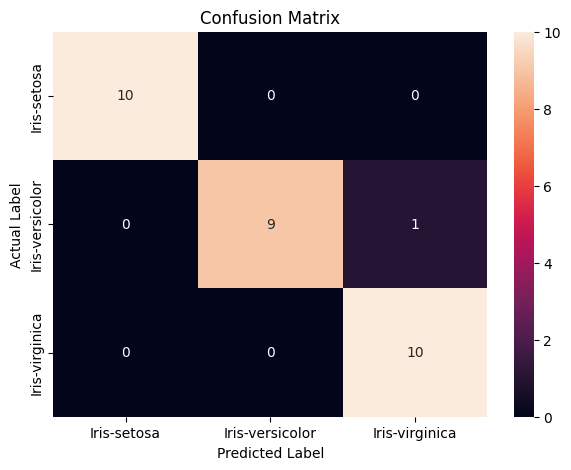

In [37]:
# ==========================================
# STEP 20 : CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Confusion Matrix")

plt.show()

In [38]:
# ==========================================
# STEP 21 : ACTUAL VS PREDICTED
# ==========================================

print("Actual Class        Predicted Class")

for actual, pred in zip(
    y_test[:10],
    predicted[:10]
):

    actual_name = encoder.inverse_transform(
        [actual.item()]
    )[0]

    pred_name = encoder.inverse_transform(
        [pred.item()]
    )[0]

    print(
        f"{actual_name:18} {pred_name}"
    )

Actual Class        Predicted Class
Iris-setosa        Iris-setosa
Iris-virginica     Iris-virginica
Iris-versicolor    Iris-versicolor
Iris-versicolor    Iris-versicolor
Iris-setosa        Iris-setosa
Iris-versicolor    Iris-versicolor
Iris-setosa        Iris-setosa
Iris-setosa        Iris-setosa
Iris-virginica     Iris-virginica
Iris-versicolor    Iris-versicolor


In [39]:
# ==========================================
# STEP 22 : PREDICT NEW FLOWER
# ==========================================

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

# Scale using the same scaler
new_flower_scaled = scaler.transform(
    new_flower
)

# Convert to tensor
new_flower_tensor = torch.tensor(
    new_flower_scaled,
    dtype=torch.float32
)

# Predict
model.eval()

with torch.no_grad():

    output = model(
        new_flower_tensor
    )

    predicted_class = torch.argmax(
        output,
        dim=1
    ).item()

predicted_name = encoder.inverse_transform(
    [predicted_class]
)[0]

print(
    "Predicted Flower:",
    predicted_name
)

Predicted Flower: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================
# STEP 23 : CONCLUSION
# ==========================================

print("""
CONCLUSION
==========

An Artificial Neural Network for multi-class
classification was successfully implemented using PyTorch
on the Iris dataset.

The four flower measurements were used as input features,
and the flower species was used as the target variable.

The categorical target values were encoded into numerical
class labels and the input features were standardized.

An ANN containing an input layer, hidden layers and an
output layer with three neurons was created.

CrossEntropyLoss was used as the loss function and Adam
was used as the optimizer. The model was trained using
forward propagation, backpropagation and parameter updates.

The model was evaluated using test accuracy,
classification report and confusion matrix.

Training loss and training accuracy were visualized to
observe the learning process.

The results show that the ANN can effectively classify
Iris flowers into Setosa, Versicolor and Virginica classes.
""")